In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/df_clean.csv')

# Drop the rows with NaNs in our lag features before doing ML
# We lose about 1,600 rows (1% of the data)
df_ml = df.dropna(subset=['temp_lag_7']).copy()

print(f"✅ Data loaded for Anomaly Detection: {df_ml.shape}")

✅ Data loaded for Anomaly Detection: (143611, 57)


In [2]:
# Select core weather features to scan for anomalies
features = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']

# Initialize the model 
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit and predict (-1 means Anomaly, 1 means Normal)
print("Training Isolation Forest...")
df_ml['anomaly_flag'] = iso_forest.fit_predict(df_ml[features])

anomaly_counts = df_ml['anomaly_flag'].value_counts()
print(f"\nNormal records: {anomaly_counts[1]:,}")
print(f"Anomalies detected: {anomaly_counts[-1]:,}")

Training Isolation Forest...

Normal records: 142,174
Anomalies detected: 1,437


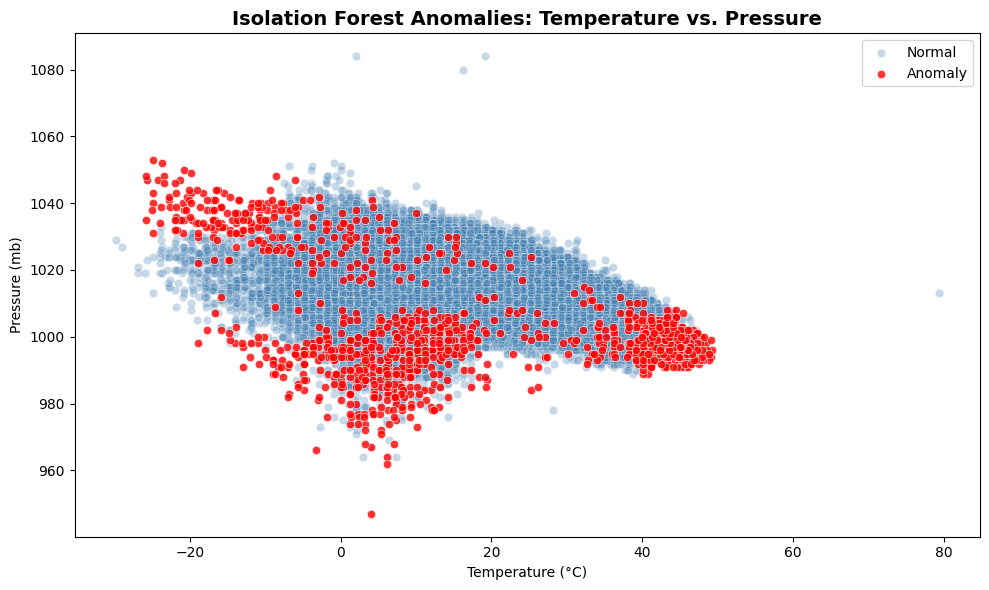

✅ Saved: 10_anomaly_scatter.png


In [3]:
# Plot Temperature vs Pressure, colored by Anomaly Flag
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_ml[df_ml['anomaly_flag'] == 1], 
    x='temperature_celsius', y='pressure_mb', 
    color='steelblue', alpha=0.3, label='Normal'
)

sns.scatterplot(
    data=df_ml[df_ml['anomaly_flag'] == -1], 
    x='temperature_celsius', y='pressure_mb', 
    color='red', alpha=0.8, label='Anomaly'
)

plt.title('Isolation Forest Anomalies: Temperature vs. Pressure', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (mb)')
plt.legend()
plt.tight_layout()

plt.savefig('../outputs/10_anomaly_scatter.png', dpi=150)
plt.show()
print("✅ Saved: 10_anomaly_scatter.png")

In [4]:
anomalies = df_ml[df_ml['anomaly_flag'] == -1]

print("Top 5 Countries with the most anomalies:")
print(anomalies['country'].value_counts().head(5))

print("\nAnomalies by Season:")
print(anomalies['season'].value_counts())

df_ml.to_csv('../data/df_model_ready.csv', index=False)
print("\n✅ Saved: data/df_model_ready.csv")

Top 5 Countries with the most anomalies:
country
Kuwait          172
Iceland         142
Iraq            119
Saudi Arabia     92
Qatar            85
Name: count, dtype: int64

Anomalies by Season:
season
Summer    656
Winter    459
Spring    173
Autumn    149
Name: count, dtype: int64

✅ Saved: data/df_model_ready.csv


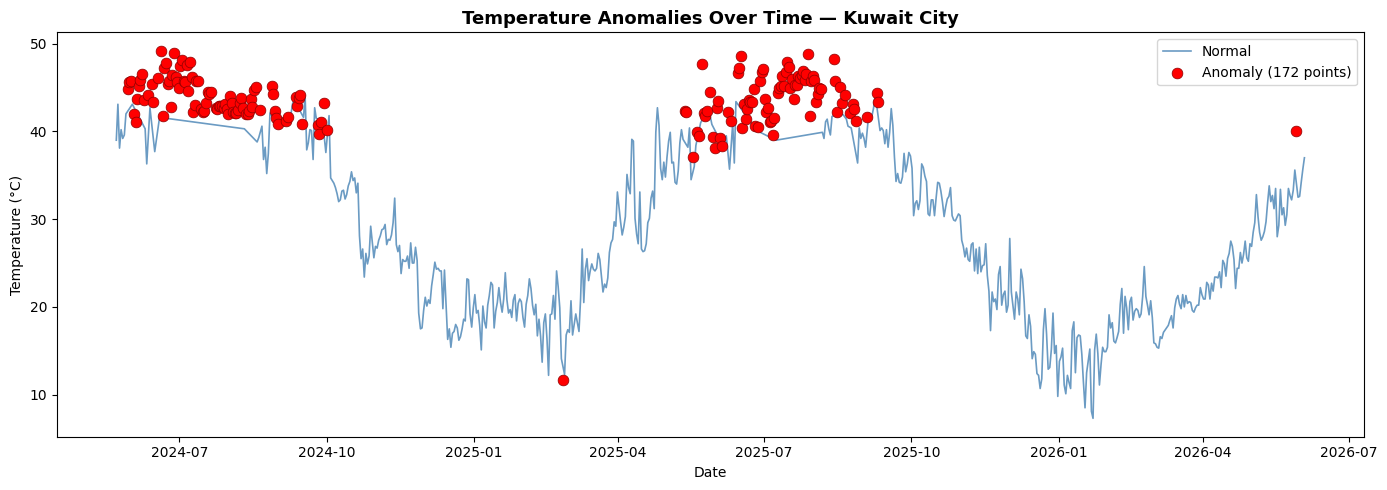

✅ Saved: 11_anomaly_timeseries.png  |  City: Kuwait City


In [5]:
# Time series: anomaly points marked on one city's temperature history
top_city = anomalies['location_name'].value_counts().idxmax()
city_data = df_ml[df_ml['location_name'] == top_city].copy()
city_data['last_updated'] = pd.to_datetime(city_data['last_updated'])
city_data = city_data.sort_values('last_updated')

city_normal   = city_data[city_data['anomaly_flag'] ==  1]
city_anom     = city_data[city_data['anomaly_flag'] == -1]

plt.figure(figsize=(14, 5))
plt.plot(city_normal['last_updated'], city_normal['temperature_celsius'],
         color='steelblue', linewidth=1.2, alpha=0.8, label='Normal', zorder=2)
plt.scatter(city_anom['last_updated'], city_anom['temperature_celsius'],
            color='red', s=60, zorder=4, edgecolors='darkred', linewidths=0.5,
            label=f'Anomaly ({len(city_anom)} points)')

plt.title(f'Temperature Anomalies Over Time — {top_city}', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/11_anomaly_timeseries.png', dpi=150)
plt.show()
print(f"✅ Saved: 11_anomaly_timeseries.png  |  City: {top_city}")

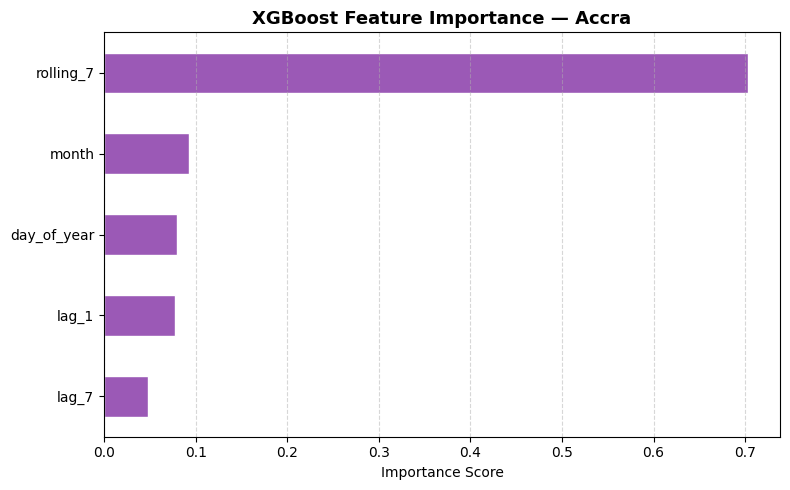

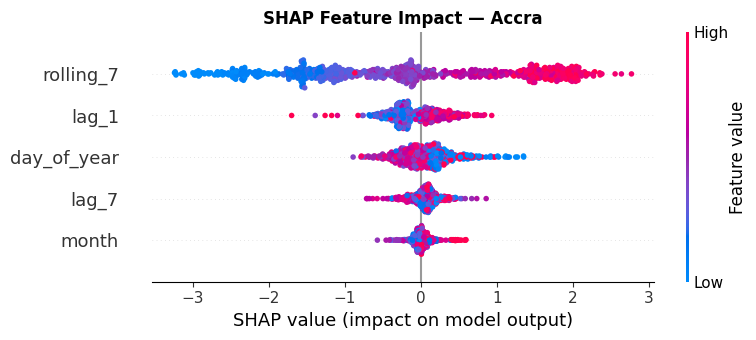

✅ City: Accra
✅ Saved: 17_feature_importance.png + 18_shap_summary.png


In [6]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Reload model and rebuild features ---
xgb = joblib.load('../outputs/xgb_model.pkl')

df = pd.read_csv('../data/df_model_ready.csv', parse_dates=['last_updated'])
CITY = df.groupby('location_name').size().idxmax()

city_daily = (
    df[df['location_name'] == CITY]
    .set_index('last_updated')['temperature_celsius']
    .resample('D').mean()
    .interpolate(method='linear')
    .dropna()
)

def build_features(series):
    d = pd.DataFrame({'y': series})
    d['lag_1']     = d['y'].shift(1)
    d['lag_7']     = d['y'].shift(7)
    d['rolling_7'] = d['y'].shift(1).rolling(7).mean()
    d['month']     = series.index.month
    d['day_of_year'] = series.index.dayofyear
    return d.dropna()

FEATURE_COLS = ['lag_1', 'lag_7', 'rolling_7', 'month', 'day_of_year']
all_feat = build_features(city_daily)

#Plot 1: Built-in XGBoost feature importance
importances = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#9B59B6', edgecolor='white')
ax.set_title(f'XGBoost Feature Importance — {CITY}', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/17_feature_importance.png', dpi=150)
plt.show()

#Plot 2: SHAP Summary
explainer  = shap.TreeExplainer(xgb)
shap_vals  = explainer.shap_values(all_feat[FEATURE_COLS])

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_vals, all_feat[FEATURE_COLS], show=False)
plt.title(f'SHAP Feature Impact — {CITY}', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/18_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ City: {CITY}")
print("✅ Saved: 17_feature_importance.png + 18_shap_summary.png")

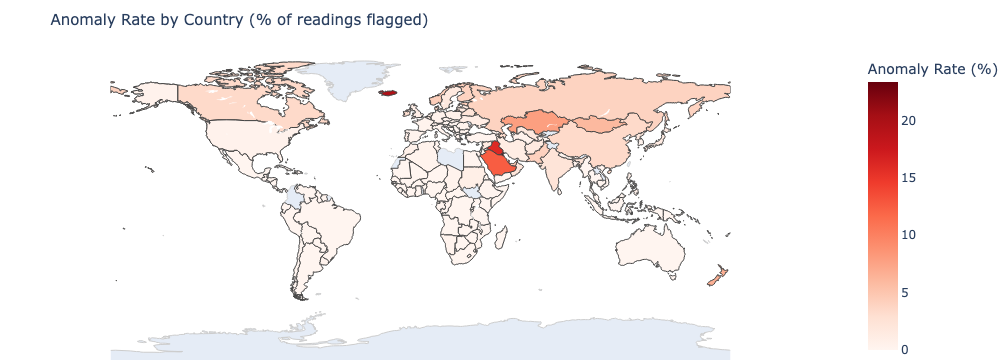

✅ Saved: 19_choropleth_anomaly_rate.html


In [12]:
import plotly.express as px

df_spatial = pd.read_csv('../data/df_model_ready.csv')

# Calculate anomaly rate per country
anomaly_by_country = (
    df_spatial.groupby('country')
    .agg(total=('anomaly_flag', 'count'),
         anomalies=('anomaly_flag', lambda x: (x == -1).sum()))
    .assign(anomaly_rate_pct=lambda x: (x['anomalies'] / x['total'] * 100).round(2))
    .reset_index()
)

fig = px.choropleth(
    anomaly_by_country,
    locations='country',
    locationmode='country names',
    color='anomaly_rate_pct',
    color_continuous_scale='Reds',
    title='Anomaly Rate by Country (% of readings flagged)',
    labels={'anomaly_rate_pct': 'Anomaly Rate (%)'},
    hover_name='country',
    hover_data={'anomaly_rate_pct': ':.2f', 'anomalies': True, 'total': True}
)
fig.update_layout(
    title_font_size=15,
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor='#CCC'),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig.write_html('../outputs/19_choropleth_anomaly_rate.html')
fig.show()
print("✅ Saved: 19_choropleth_anomaly_rate.html")

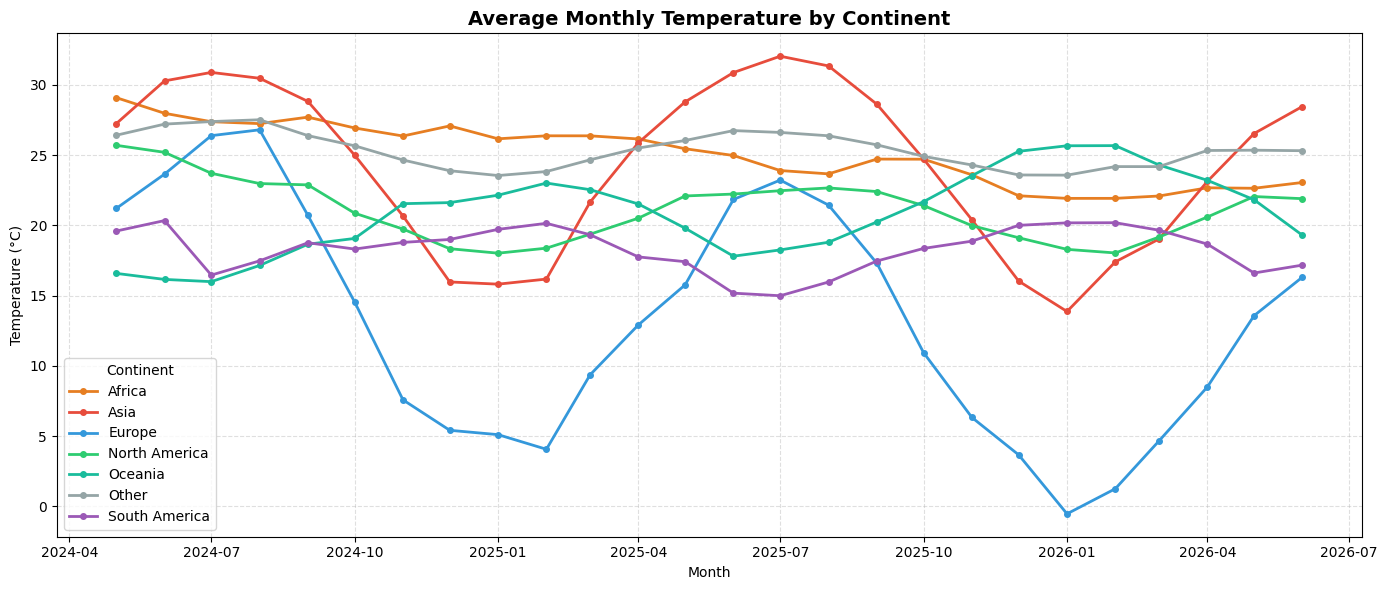

✅ Saved: 20_temp_by_continent.png


In [8]:
df_geo = pd.read_csv('../data/df_model_ready.csv', parse_dates=['last_updated'])

# Safety check — build continent column if missing
if 'continent' not in df_geo.columns:
    continent_map = {
        'Ghana':'Africa','Kuwait':'Asia','Iceland':'Europe','Iraq':'Asia',
        'Saudi Arabia':'Asia','Qatar':'Asia','Australia':'Oceania',
        'United States':'North America','Brazil':'South America',
        'United Kingdom':'Europe','India':'Asia','China':'Asia',
        'Russia':'Europe','Japan':'Asia','Germany':'Europe',
        'France':'Europe','Canada':'North America','Mexico':'North America',
        'South Africa':'Africa','Nigeria':'Africa','Argentina':'South America',
        'Indonesia':'Asia','Turkey':'Asia','Spain':'Europe','Italy':'Europe',
    }
    df_geo['continent'] = df_geo['country'].map(continent_map).fillna('Other')

df_geo['month_year'] = df_geo['last_updated'].dt.to_period('M').dt.to_timestamp()

continent_monthly = (
    df_geo.groupby(['continent', 'month_year'])['temperature_celsius']
    .mean().reset_index()
)

continent_colors = {
    'Africa':        '#E67E22',
    'Asia':          '#E74C3C',
    'Europe':        '#3498DB',
    'North America': '#2ECC71',
    'South America': '#9B59B6',
    'Oceania':       '#1ABC9C',
    'Other':         '#95A5A6'
}

fig, ax = plt.subplots(figsize=(14, 6))
for continent in sorted(continent_monthly['continent'].unique()):
    sub   = continent_monthly[continent_monthly['continent'] == continent]
    color = continent_colors.get(continent, '#95A5A6')
    ax.plot(sub['month_year'], sub['temperature_celsius'],
            label=continent, color=color, linewidth=2,
            marker='o', markersize=4)

ax.set_title('Average Monthly Temperature by Continent', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.legend(title='Continent', fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/20_temp_by_continent.png', dpi=150)
plt.show()
print("✅ Saved: 20_temp_by_continent.png")

Air quality columns found: 8
['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index']


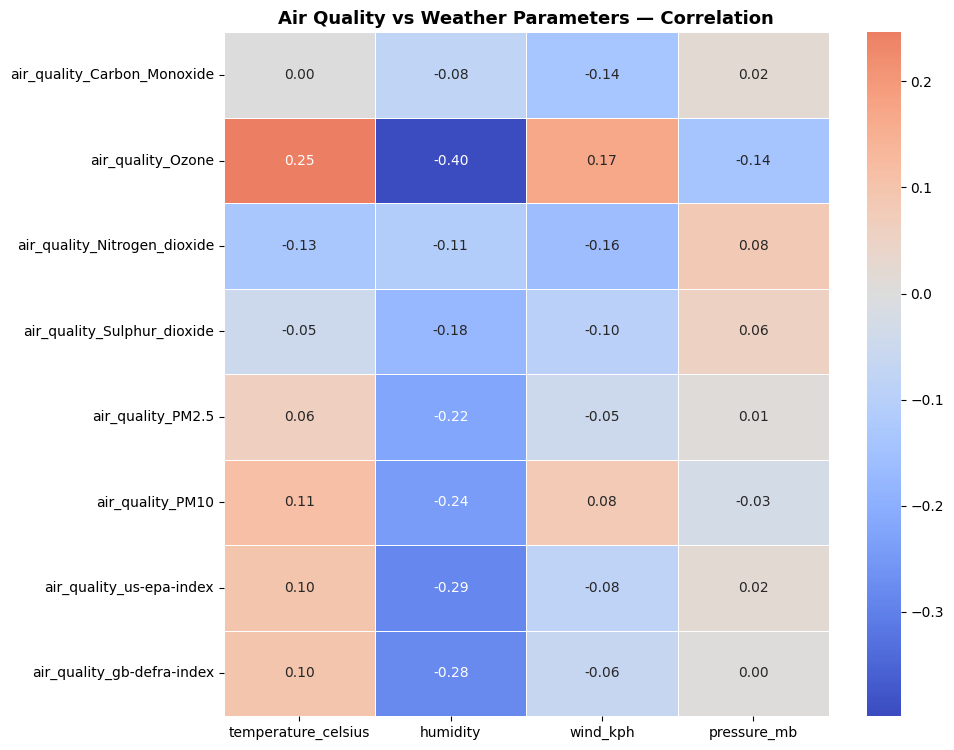

✅ Saved: 21_air_quality_correlation.png


In [11]:
import seaborn as sns

df_air = pd.read_csv('../data/df_model_ready.csv')

aq_cols      = [c for c in df_air.columns if 'air_quality' in c.lower()]
weather_cols = ['temperature_celsius', 'humidity', 'wind_kph', 'pressure_mb']

print(f"Air quality columns found: {len(aq_cols)}")
print(aq_cols)

df_air[aq_cols] = df_air[aq_cols].replace(-9999, np.nan)
corr_data = df_air[aq_cols + weather_cols].corr().loc[aq_cols, weather_cols]

fig, ax = plt.subplots(figsize=(10, max(4, len(aq_cols) * 0.7 + 2)))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Air Quality vs Weather Parameters — Correlation',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/21_air_quality_correlation.png', dpi=150)
plt.show()
print("✅ Saved: 21_air_quality_correlation.png")